# SPEAR-HI25 (2025-2059)|(2060-2094) minus (1991-2024)
# Map vars (Frequency, Intensity, Duration)
(>=5 consecutive days w/ a gap of >=3 days in between events for each grid cell)

|  | OISST | ERA5 | SPEAR-LO | SPEAR-HI |
| :---------- | :---------- | :----------: | ----------: | ----------: |
| Temperature | SST | SST | SST | SST |
| Sampling<br>frequency | Daily | Daily | Daily | Daily |
| Lat/Lon<br>resolution | 0.25˚ x 0.25˚ | 0.25˚ x 0.25˚ | 1˚ x 1˚ | 0.25˚ x 0.25˚ |
|Time period | 1981-09 : 2025-09 | 1983-01 : 2021-06 | 1981-09 : 2010-12 | 1991-01 : 2100-01 |

In [1]:
import xarray as xr
import pandas as pd
import json
import numpy as np
import cmocean
import cartopy.crs as ccrs #cartopy coord ref sys
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap
import time
from tqdm import tqdm
import glob
import os
from collections import defaultdict
import xesmf as xe
import ast #for parsing through events_by_cell.json file
import re

## Open all ensemble members for `Freq`, `Dur` and `Int` in the 3 epochs

In [2]:
%%time
#1991 - 2024
base_path = '/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_1991-2024/map_vars'

files_int = sorted(glob.glob(f'{base_path}/mean_mhw_intensity_sphi*.nc'))
mean_mhw_intensity_lds = []
for f in files_int:
    ds = xr.open_dataset(f, chunks={})
    da = next(iter(ds.data_vars.values()))
    #take the # in filename and add it to darr name
    ens = os.path.basename(f).split('_sphi')[-1].split('.nc')[0] 
    da = da.rename(f'{ens}').drop_vars('quantile')
    mean_mhw_intensity_lds.append(da)
mean_mhw_intensity91 = xr.concat(mean_mhw_intensity_lds, dim="ensemble") #####----------
#mean_mhw_intensity91 = mhw_intensity91.mean('time')
#mhw_instensity_std91 = mhw_intensity91.std('time')

files_freq = sorted(glob.glob(f'{base_path}/event_counts_sphi*.nc'))
event_count91_lds = []
for f in files_freq:
    ds = xr.open_dataset(f, chunks={})
    da = next(iter(ds.data_vars.values()))
    #take the # in filename and add it to darr name
    ens = os.path.basename(f).split('_sphi')[-1].split('.nc')[0] 
    da = da.rename(f'{ens}')
    event_count91_lds.append(da)
event_count91 = xr.concat(event_count91_lds, dim="ensemble") #####----------
freq91 = event_count91 / 34

median_duration91 = xr.open_dataset(f'{base_path}/median_duration.nc', chunks={}) #####----------
#duration_std91 = xr.open_dataset(f'{base_path}/duration_std.nc', chunks={} #####----------

CPU times: user 351 ms, sys: 89.8 ms, total: 441 ms
Wall time: 1.47 s


In [3]:
freq91

<xarray.DataArray '01' (ensemble: 30, yT: 90, xT: 325)> Size: 7MB
dask.array<truediv, shape=(30, 90, 325), dtype=float64, chunksize=(1, 90, 325), chunktype=numpy.ndarray>
Coordinates:
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Dimensions without coordinates: ensemble

In [4]:
mean_mhw_intensity91

<xarray.DataArray '01' (ensemble: 30, yT: 90, xT: 325)> Size: 7MB
dask.array<concatenate, shape=(30, 90, 325), dtype=float64, chunksize=(1, 90, 325), chunktype=numpy.ndarray>
Coordinates:
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Dimensions without coordinates: ensemble
Attributes:
    units:          deg-C
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    axis:           T
    calendar_type:  JULIAN
    bounds:         time_bnds

In [5]:
def open_datasets(da_name, period):

    base_path = f'/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_{period}/map_vars'
    files = sorted(glob.glob(f'{base_path}/*{da_name}*.nc'))
    
    dsets = []
    for f in files:
        ds = xr.open_dataset(f)
        # get the only/main variable in file
        da = list(ds.data_vars.values())[0]
        # extract ensemble number from filename (_01.nc, _02.nc, etc.)
        ens = int(re.search(r'(\d+)\.nc$', f).group(1))
        if "ensemble" not in da.dims:
            da = da.expand_dims(ensemble=[ens])
        else:
            # if ensemble already exists, just assign correct label
            da = da.assign_coords(ensemble=[ens])
        dsets.append(da)

    return xr.concat(dsets, dim="ensemble")

#2025-2059
median_duration25 = open_datasets('median_duration', '2025-2059')
mean_mhw_intensity25 = open_datasets('mean_mhw_intensity', '2025-2059')
event_count25 = open_datasets('event_count', '2025-2059')
freq25 = event_count25 / 34
#duration25 = open_datasets('duration', '2025-2059')
#duration_std_list25 = [duration25.isel(ensemble=i).duration.std('event') for i in np.arange(0,30)]
#duration_std25 = xr.concat(duration_std_list25, dim=('ensemble'))

#2060-2094
median_duration60 = open_datasets('median_duration', '2060-2094')
mean_mhw_intensity60 = open_datasets('mean_mhw_intensity', '2060-2094')
event_count60 = open_datasets('event_count', '2060-2094')
freq60 = event_count60 / 34

In [6]:
median_duration25

<xarray.DataArray 'median_duration' (ensemble: 30, yT: 90, xT: 325)> Size: 7MB
array([[[10. , 10. , 10. , ...,  9. ,  9. ,  9. ],
        [10. , 10. , 10. , ...,  9. ,  8.5,  8. ],
        [ 9.5, 10. , 10.5, ..., 10. ,  8. ,  9. ],
        ...,
        [ nan,  nan,  nan, ..., 13. , 12. , 11. ],
        [ nan,  nan,  nan, ..., 11. , 11. , 11. ],
        [ nan,  nan,  nan, ..., 10.5, 11. , 11. ]],

       [[ 9. , 10. ,  9. , ..., 10. , 10. , 11. ],
        [11. , 11. ,  9.5, ..., 11. , 11. , 11. ],
        [11. , 10.5, 10. , ...,  9. ,  9. ,  9. ],
        ...,
        [ nan,  nan,  nan, ..., 13. , 11. , 14. ],
        [ nan,  nan,  nan, ..., 11. , 11. , 12. ],
        [ nan,  nan,  nan, ..., 11. , 10. , 11. ]],

       [[ 9. , 10. ,  9. , ..., 10. ,  9. , 10. ],
        [ 9. ,  9. ,  9. , ..., 10. ,  9. ,  9. ],
        [10. ,  9. ,  8. , ..., 10. , 12. , 10. ],
        ...,
...
        ...,
        [ nan,  nan,  nan, ..., 11.5, 11. , 11. ],
        [ nan,  nan,  nan, ..., 12. , 10.5, 10. ],
        [ nan,  nan,  nan, ..., 12. , 13. , 10. ]],

       [[11. , 10. , 10.5, ...,  9. , 11. ,  9. ],
        [10. , 10. , 10. , ..., 10. , 10. , 10. ],
        [ 8. ,  8. ,  9. , ..., 10. ,  9.5, 10.5],
        ...,
        [ nan,  nan,  nan, ..., 10. ,  9.5, 10.5],
        [ nan,  nan,  nan, ...,  8.5,  8. , 10. ],
        [ nan,  nan,  nan, ..., 11. , 11. , 10.5]],

       [[ 8. ,  8. ,  8. , ..., 10. , 10.5,  9. ],
        [ 9. ,  8. ,  8. , ..., 11. , 10. ,  9. ],
        [ 9.5,  8. ,  9. , ..., 11. , 10. , 10. ],
        ...,
        [ nan,  nan,  nan, ..., 12. , 10. , 12. ],
        [ nan,  nan,  nan, ...,  9. ,  9.5, 10. ],
        [ nan,  nan,  nan, ..., 10.5, 10. ,  9.5]]])
Coordinates:
  * ensemble  (ensemble) int64 240B 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * yT        (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT        (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15

In [7]:
freq25

<xarray.DataArray 'event_count' (ensemble: 30, yT: 90, xT: 325)> Size: 7MB
array([[[2.47058824, 2.47058824, 2.55882353, ..., 2.35294118,
         2.32352941, 2.35294118],
        [2.52941176, 2.44117647, 2.64705882, ..., 2.32352941,
         2.29411765, 2.38235294],
        [2.70588235, 2.67647059, 2.64705882, ..., 2.08823529,
         2.38235294, 2.29411765],
        ...,
        [0.        , 0.        , 0.        , ..., 1.91176471,
         1.82352941, 1.97058824],
        [0.        , 0.        , 0.        , ..., 1.91176471,
         1.94117647, 2.11764706],
        [0.        , 0.        , 0.        , ..., 2.        ,
         1.94117647, 2.02941176]],

       [[2.67647059, 2.47058824, 2.47058824, ..., 2.55882353,
         2.47058824, 2.38235294],
        [2.5       , 2.44117647, 2.41176471, ..., 2.41176471,
         2.5       , 2.61764706],
        [2.29411765, 2.47058824, 2.5       , ..., 2.61764706,
         2.58823529, 2.5       ],
...
        [0.        , 0.        , 0.        , ..., 2.08823529,
         2.11764706, 2.11764706],
        [0.        , 0.        , 0.        , ..., 2.23529412,
         2.26470588, 2.14705882],
        [0.        , 0.        , 0.        , ..., 2.23529412,
         2.08823529, 2.11764706]],

       [[2.32352941, 2.29411765, 2.29411765, ..., 2.5       ,
         2.58823529, 2.64705882],
        [2.26470588, 2.26470588, 2.32352941, ..., 2.38235294,
         2.58823529, 2.58823529],
        [2.29411765, 2.44117647, 2.29411765, ..., 2.38235294,
         2.61764706, 2.61764706],
        ...,
        [0.        , 0.        , 0.        , ..., 2.23529412,
         2.17647059, 1.97058824],
        [0.        , 0.        , 0.        , ..., 2.32352941,
         2.17647059, 2.14705882],
        [0.        , 0.        , 0.        , ..., 2.23529412,
         2.20588235, 2.23529412]]])
Coordinates:
  * ensemble  (ensemble) int64 240B 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * yT        (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT        (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
    time      object 8B 2025-01-01 12:00:00
Attributes:
    units:          deg-C
    long_name:      sea surface temperature
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

In [8]:
freq60

<xarray.DataArray 'event_count' (ensemble: 30, yT: 90, xT: 325)> Size: 7MB
array([[[2.35294118, 2.67647059, 2.88235294, ..., 2.47058824,
         2.29411765, 2.5       ],
        [2.58823529, 2.73529412, 2.76470588, ..., 2.26470588,
         2.38235294, 2.41176471],
        [2.73529412, 2.94117647, 2.94117647, ..., 2.44117647,
         2.47058824, 2.64705882],
        ...,
        [0.        , 0.        , 0.        , ..., 2.38235294,
         2.47058824, 2.32352941],
        [0.        , 0.        , 0.        , ..., 2.47058824,
         2.32352941, 2.38235294],
        [0.        , 0.        , 0.        , ..., 2.26470588,
         2.32352941, 2.44117647]],

       [[2.61764706, 2.61764706, 2.44117647, ..., 2.47058824,
         2.55882353, 2.55882353],
        [2.73529412, 2.61764706, 2.61764706, ..., 2.38235294,
         2.64705882, 2.47058824],
        [2.67647059, 2.64705882, 2.38235294, ..., 2.67647059,
         2.52941176, 2.29411765],
...
        [0.        , 0.        , 0.        , ..., 2.11764706,
         2.        , 1.82352941],
        [0.        , 0.        , 0.        , ..., 1.85294118,
         1.91176471, 1.76470588],
        [0.        , 0.        , 0.        , ..., 1.82352941,
         1.94117647, 2.        ]],

       [[1.94117647, 1.91176471, 1.97058824, ..., 2.20588235,
         2.08823529, 2.14705882],
        [2.05882353, 2.        , 1.88235294, ..., 2.17647059,
         2.17647059, 2.35294118],
        [2.05882353, 2.23529412, 1.91176471, ..., 2.20588235,
         2.23529412, 2.32352941],
        ...,
        [0.        , 0.        , 0.        , ..., 2.05882353,
         2.08823529, 2.17647059],
        [0.        , 0.        , 0.        , ..., 2.17647059,
         2.26470588, 2.32352941],
        [0.        , 0.        , 0.        , ..., 2.14705882,
         2.29411765, 2.17647059]]])
Coordinates:
  * ensemble  (ensemble) int64 240B 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * yT        (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT        (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
    time      object 8B 2060-01-01 12:00:00
Attributes:
    units:          deg-C
    long_name:      sea surface temperature
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

## Plotting func

In [9]:
def cartopy_plot(da, cmap_choice, var_title=None, norm=None, ax=None):
    if ax is None:
        raise ValueError("This function now requires an axis when used for panels")

    ax.set_extent([-98, -60, 17.5, 31], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='0.5'))

    # ---- model agnostic: infer coord names ----
    lat_name = next(c for c in ['lat','latitude','yT','yh'] if c in da.coords)
    lon_name = next(c for c in ['lon','longitude','xT','xh'] if c in da.coords)
    
    if lat_name is None or lon_name is None:
        raise ValueError(f"Could not infer lat/lon coordinates. " f"Found coords: {list(da.coords)}")
    # --------------------------------------------
    im = ax.pcolormesh(da[lon_name], da[lat_name], da, transform=ccrs.PlateCarree(), 
                       cmap=cmap_choice, norm=norm)

    ax.set_title(var_title, fontsize=10)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.xlabels_top = False
    gl.ylabels_right = False

    return im # return the image for optional colorbar handling

In [10]:
def cartopy_plot_single(da, cmap_choice, cbar_label, var_title, vmin=None, vmax=None, norm=None, quiver=True, hatch_mask=None):
    proj = ccrs.Mercator() #with Mercator you can put lat lon values.
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=proj))
    ax.set_extent([-98, -60, 17.5, 31], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor='face',
                                            facecolor='0.5'))
    # ---- infer coord names if not provided ----
    lat_candidates = ['lat', 'latitude', 'yT', 'yh']
    lon_candidates = ['lon', 'longitude', 'xT', 'xh']

    lat_name = next((c for c in lat_candidates if c in da.coords), None)
    lon_name = next((c for c in lon_candidates if c in da.coords), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            f"Could not infer lat/lon coordinates. "
            f"Found coords: {list(da.coords)}"
        )

    lats = da[lat_name]
    lons = da[lon_name]

    # ---- normalization logic ----
    if norm is None:
        # simple linear scaling
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        # override norm limits if vmin/vmax are supplied
        if vmin is not None:
            norm.vmin = vmin
        if vmax is not None:
            norm.vmax = vmax
    # -------------------------------------------------------------------------------
    im = ax.pcolormesh(lons, lats, da, transform=ccrs.PlateCarree(), 
                       norm=norm, cmap=cmap_choice)
    # ---- optional stippling/hatching ----
    if hatch_mask is not None:
        plt.rcParams['hatch.color'] = 'lime'
        ax.contourf(hatch_mask.xT, hatch_mask.yT, hatch_mask, levels=[0.5, 1.5], hatches=['xxx'], 
                    colors='none', transform=ccrs.PlateCarree())
    
    cb = fig.colorbar(im, ax=ax, shrink=0.25, pad=0.1)
    cb.set_label(fr"{cbar_label}", labelpad=8, fontsize=12)
    g1 = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    g1.xlabels_top = False
    g1.ylabels_right = False
    plt.title(f'{var_title}', fontsize=14, y=1.09)

## Ensemble Mean Maps

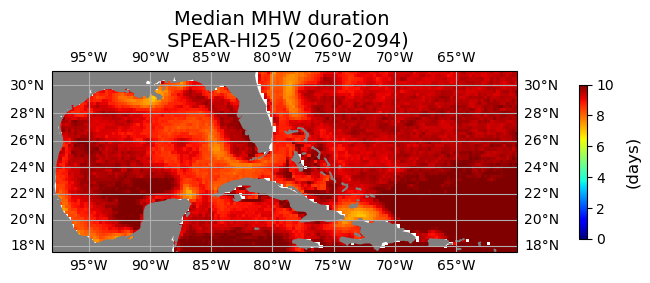

In [11]:
cartopy_plot_single(median_duration60.mean('ensemble'), 'jet', '(days)', 
             'Median MHW duration \n SPEAR-HI25 (2060-2094)', vmin=0, vmax=10);#if time res is daily

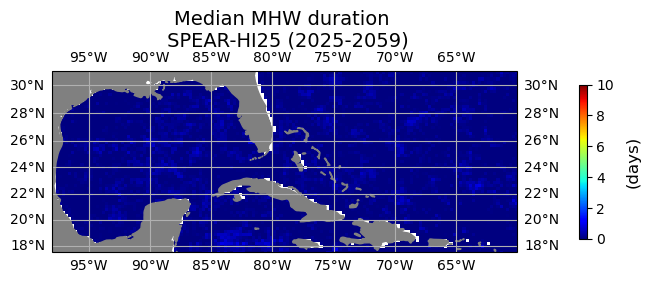

In [12]:
cartopy_plot_single((median_duration60-median_duration25).mean('ensemble'), 'jet', '(days)', 
             'Median MHW duration \n SPEAR-HI25 (2025-2059)', vmin=0, vmax=10);#if time res is daily

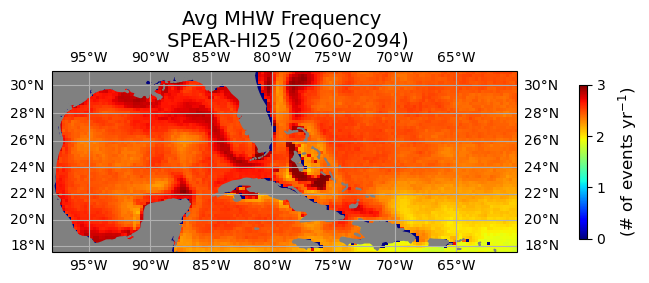

In [13]:
cartopy_plot_single(freq60.mean('ensemble'), 'jet', r'(# of events yr$^{-1}$)', 
                    'Avg MHW Frequency \n SPEAR-HI25 (2060-2094)', vmin=0, vmax=3);

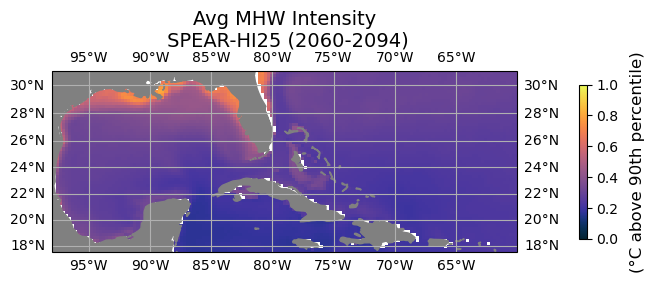

In [14]:
cartopy_plot_single(mean_mhw_intensity60.mean('ensemble'), cmocean.cm.thermal, '(°C above 90th percentile)', 
             'Avg MHW Intensity\n SPEAR-HI25 (2060-2094)', vmin=0, vmax=1); 

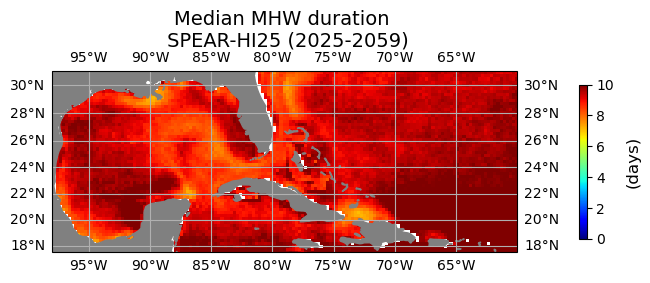

In [15]:
cartopy_plot_single(median_duration25.mean('ensemble'), 'jet', '(days)', 
             'Median MHW duration \n SPEAR-HI25 (2025-2059)', vmin=0, vmax=10);#if time res is daily

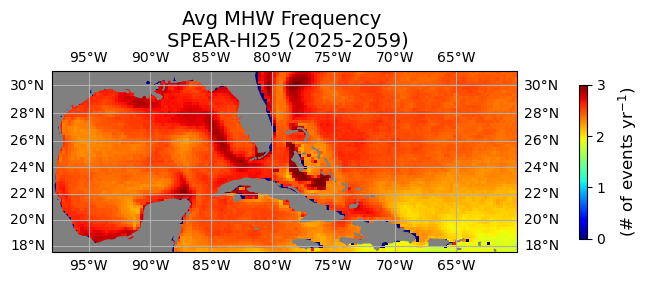

In [16]:
cartopy_plot_single(freq25.mean('ensemble'), 'jet', r'(# of events yr$^{-1}$)', 
                    'Avg MHW Frequency \n SPEAR-HI25 (2025-2059)', vmin=0, vmax=3);

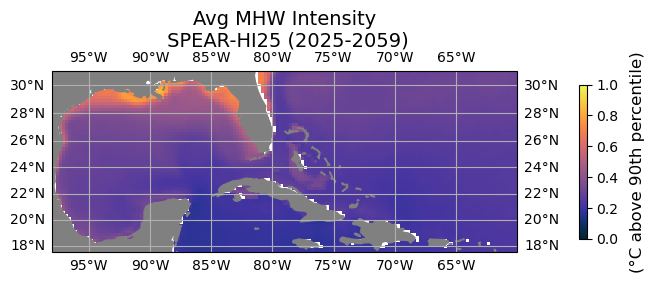

In [17]:
cartopy_plot_single(mean_mhw_intensity25.mean('ensemble'), cmocean.cm.thermal, '(°C above 90th percentile)', 
             'Avg MHW Intensity\n SPEAR-HI25 (2025-2059)', vmin=0, vmax=1); 

## Difference maps (ensemble mean)

In [18]:
freq_diff_2591 = freq25 - freq91
int_diff_2591 = mean_mhw_intensity25 - mean_mhw_intensity91
dur_diff_2591 = median_duration25 - median_duration91.__xarray_dataarray_variable__

freq_diff_6091 = freq60 - freq91
int_diff_6091 = mean_mhw_intensity60 - mean_mhw_intensity91
dur_diff_6091 = median_duration60 - median_duration91.__xarray_dataarray_variable__

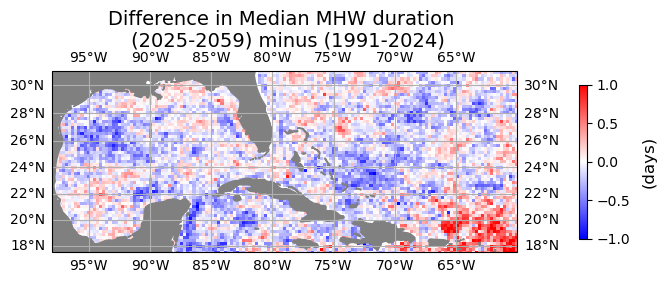

In [19]:
cartopy_plot_single(dur_diff_2591.mean('ensemble'), 'bwr', '(days)', 
             'Difference in Median MHW duration \n (2025-2059) minus (1991-2024)', vmin=-1, vmax=1);

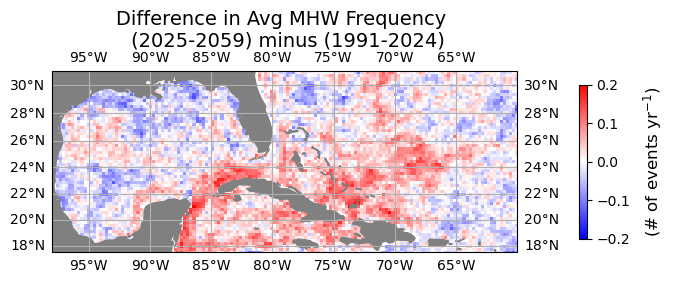

In [20]:
cartopy_plot_single(freq_diff_2591.mean('ensemble'), 'bwr', r'(# of events yr$^{-1}$)', 
                    'Difference in Avg MHW Frequency \n (2025-2059) minus (1991-2024)', vmin=-0.2, vmax=0.2);

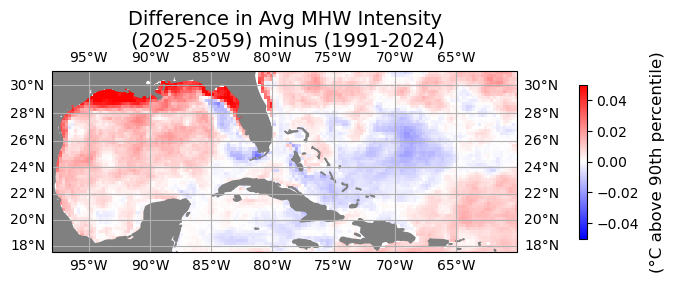

In [21]:
cartopy_plot_single(int_diff_2591.mean('ensemble'), 'bwr', '(°C above 90th percentile)', 
             'Difference in Avg MHW Intensity\n (2025-2059) minus (1991-2024)', vmin=-0.05, vmax=0.05); 

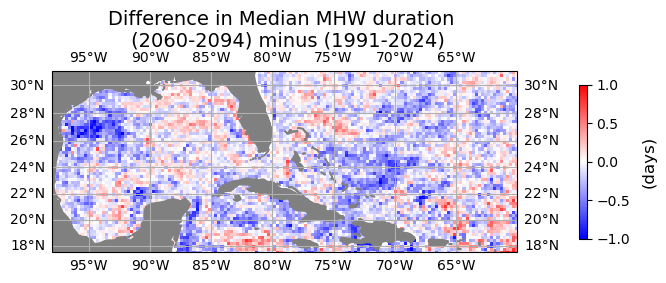

In [22]:
cartopy_plot_single(dur_diff_6091.mean('ensemble'), 'bwr', '(days)', 
             'Difference in Median MHW duration \n (2060-2094) minus (1991-2024)', vmin=-1, vmax=1);

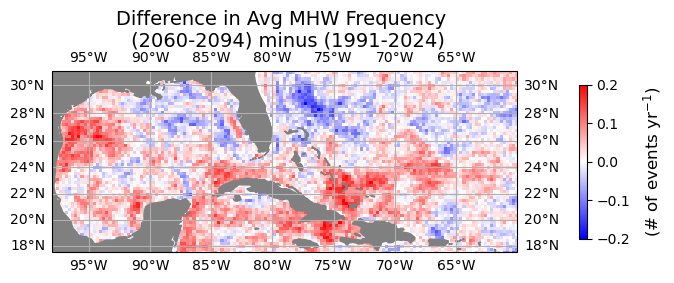

In [23]:
cartopy_plot_single(freq_diff_6091.mean('ensemble'), 'bwr', r'(# of events yr$^{-1}$)', 
                    'Difference in Avg MHW Frequency \n (2060-2094) minus (1991-2024)', vmin=-0.2, vmax=0.2);

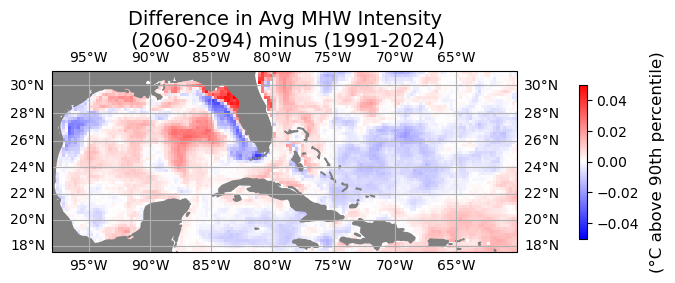

In [24]:
cartopy_plot_single(int_diff_6091.mean('ensemble'), 'bwr', '(°C above 90th percentile)', 
             'Difference in Avg MHW Intensity\n (2060-2094) minus (1991-2024)', vmin=-0.05, vmax=0.05); 

## Difference maps with stippling

Large SNR
- ensemble mean difference is large
- members cluster around that response
- robust forced signal

Small SNR
- ensemble members differ substantially
- change is weak relative to variability
- less confidence in local response

In [25]:
def robust_signal(metric_difference):
    ens_mean = metric_difference.mean('ensemble')
    #fraction of members agreeing at each grid cell.
    agreement = (np.sign(metric_difference)== np.sign(ens_mean)).mean('ensemble')
    #“How large is the projected change relative to inter-member variability?” | “Does the forced response emerge from ensemble spread?”
    snr = abs(ens_mean) / metric_difference.std('ensemble')
    robust = (agreement >= 0.7) & (snr >= 0.5)

    return robust

robust_freq_diff_2591 = robust_signal(freq_diff_2591)
robust_int_diff_2591 = robust_signal(int_diff_2591)
robust_dur_diff_2591 = robust_signal(dur_diff_2591)

robust_freq_diff_6091 = robust_signal(freq_diff_6091)
robust_int_diff_6091 = robust_signal(int_diff_6091)
robust_dur_diff_6091 = robust_signal(dur_diff_6091)

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


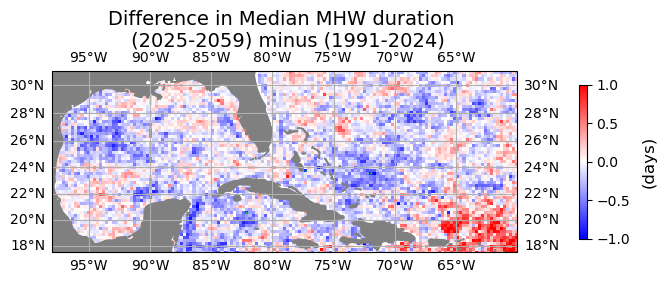

In [26]:
cartopy_plot_single(dur_diff_2591.mean('ensemble'), 'bwr', '(days)', 
             'Difference in Median MHW duration \n (2025-2059) minus (1991-2024)', vmin=-1, vmax=1, hatch_mask=robust_dur_diff_2591);

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


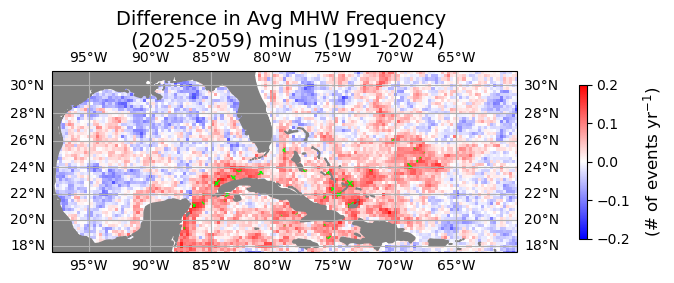

In [27]:
cartopy_plot_single(freq_diff_2591.mean('ensemble'), 'bwr', r'(# of events yr$^{-1}$)', 
                    'Difference in Avg MHW Frequency \n (2025-2059) minus (1991-2024)', vmin=-0.2, vmax=0.2, hatch_mask=robust_freq_diff_2591);

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


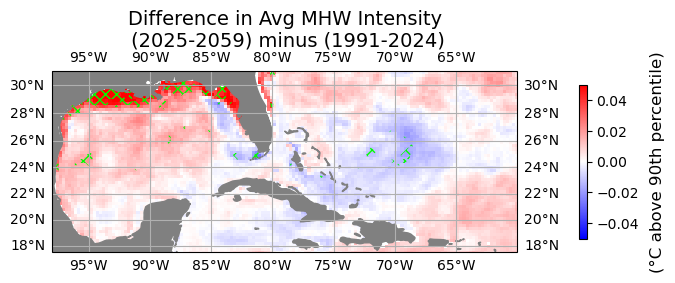

In [28]:
cartopy_plot_single(int_diff_2591.mean('ensemble'), 'bwr', '(°C above 90th percentile)', 
             'Difference in Avg MHW Intensity\n (2025-2059) minus (1991-2024)', vmin=-0.05, vmax=0.05, hatch_mask=robust_int_diff_2591); 

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


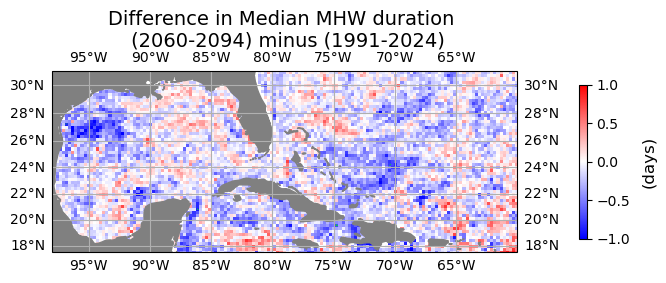

In [29]:
cartopy_plot_single(dur_diff_6091.mean('ensemble'), 'bwr', '(days)', 
             'Difference in Median MHW duration \n (2060-2094) minus (1991-2024)', vmin=-1, vmax=1, hatch_mask=robust_dur_diff_6091);

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


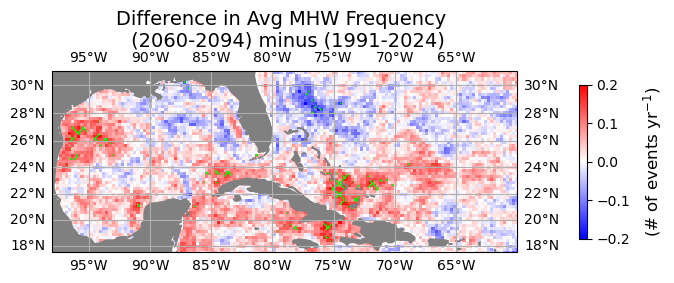

In [30]:
cartopy_plot_single(freq_diff_6091.mean('ensemble'), 'bwr', r'(# of events yr$^{-1}$)', 
                    'Difference in Avg MHW Frequency \n (2060-2094) minus (1991-2024)', vmin=-0.2, vmax=0.2, hatch_mask=robust_freq_diff_6091);

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


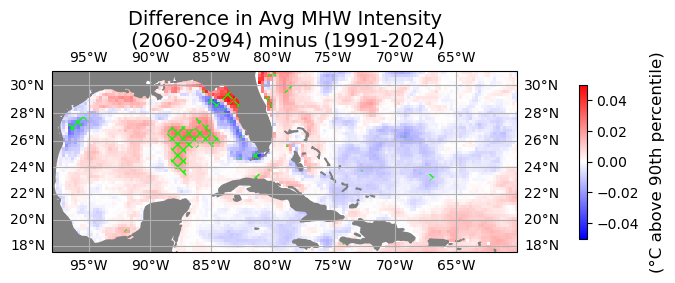

In [31]:
cartopy_plot_single(int_diff_6091.mean('ensemble'), 'bwr', '(°C above 90th percentile)', 
             'Difference in Avg MHW Intensity\n (2060-2094) minus (1991-2024)', vmin=-0.05, vmax=0.05, hatch_mask=robust_int_diff_6091); 